In [39]:
import pandas as pd
import os
import sys
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
sys.path.append(os.path.abspath(".."))
from scripts.utils import make_engine
from pathlib import Path

In [40]:
# create engine
engine = make_engine()

# read SQL query
BASE_DIR = Path.cwd().parent
sql_query = BASE_DIR / "queries" / "recency.sql"
with open(sql_query, "r") as file:
    sql_query = file.read()

# get df
df = pd.read_sql_query(sql_query, con=engine)

df


,customer_id,days_since_last_order
0,C0001,587
1,C0002,93
2,C0003,374
3,C0004,92
4,C0005,589
...,...,...
433,C0496,43
434,C0497,502
435,C0498,362
436,C0499,139


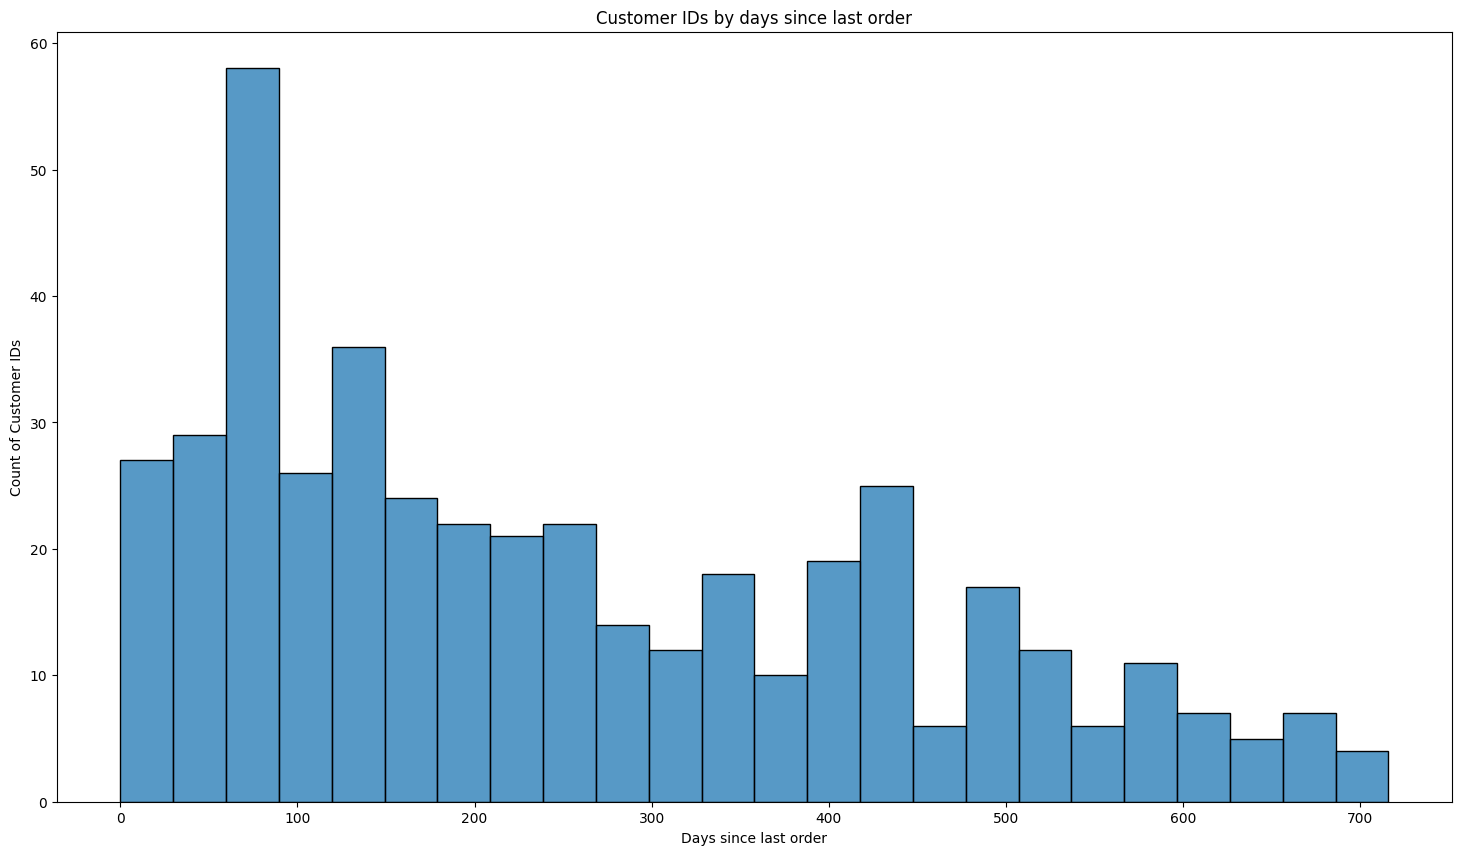

In [44]:
plt.figure(figsize=(18,10))
sns.histplot(data=df, x="days_since_last_order", bins=24)
plt.title("Customer IDs by days since last order")
plt.xlabel("Days since last order")
plt.ylabel("Count of Customer IDs")
plt.show()

In [45]:
frequency_query = "SELECT customer_id, COUNT(order_id) AS total_orders FROM orders GROUP BY customer_id" 
df2 = pd.read_sql_query(frequency_query, con=engine)

df2 = df2.groupby("total_orders")["customer_id"].count().reset_index()
df2["percentage"] = (df2["customer_id"] / df2["customer_id"].sum()) * 100

df2

,total_orders,customer_id,percentage
0,1,102,22.466960
1,2,119,26.211454
2,3,110,24.229075
3,4,65,14.317181
4,5,39,8.590308
5,6,10,2.202643
6,7,7,1.541850
7,8,2,0.440529


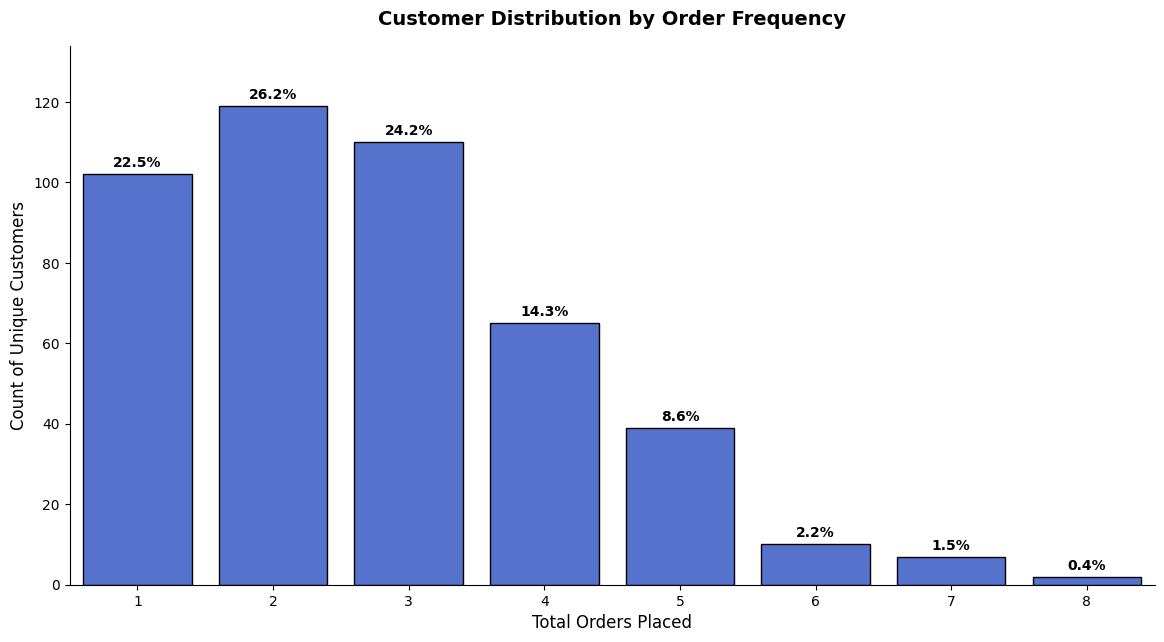

In [46]:
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=df2, x="total_orders", y="customer_id", color="royalblue", edgecolor="black")

# Add the percentage labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    # Calculate the percentage based on your table's data
    percentage = (height / df2["customer_id"].sum()) * 100
    ax.annotate(f'{percentage:.1f}%', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 8), 
                textcoords='offset points',
                fontweight='bold')

plt.title("Customer Distribution by Order Frequency", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Total Orders Placed", fontsize=12)
plt.ylabel("Count of Unique Customers", fontsize=12)
plt.ylim(0, df2["customer_id"].max() + 15) # Leave room for labels
sns.despine() # Clean up the top and right borders